# Step 5: Checks and summary

Three things in this notebook:

1. A salt budget check. Melting adds fresh water to the cavity, which should lower the total salt content of the ocean by a predictable amount. I check that the model's salt change matches the melt it reports.
2. A summary table and a summary figure of every experiment in steps 2 to 7.
3. What these results mean for the melt rule I assumed in project 14 (melt = 10 m/yr per °C² x T²).

I load the libraries and shared functions.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from MITgcmutils import rdmds

sys.path.append("../src")   # isomip_tools.py lives in the project's src/ folder
from isomip_tools import read_grid, output_iterations, read_field, NX, NY, NR, DELTA_T

RUNS = os.path.expanduser("~/mitgcm_runs/isomip")
INPUT = os.path.join(RUNS, "source_copy", "input")
FIG_DIR = "../figures"
DATA_DIR = "../data"
RHO_CONST = 1030.0               # rhoConst in the isomip 'data' file (kg/m^3)
MONTH = 2592000.0                # length of one diagnostics period (30 days, in s)
SALT_TO_HEAT = 5.05e-3           # SHELFICEsaltToHeatRatio default: gamma_S / gamma_T

## 1. Salt budget of the sealed baseline

I use the step 2 baseline because it is a closed box: no restoring and no open boundary, so the only thing that changes the salt is the ice. In this setup the fresh water is not added as volume; instead the model removes salt (a "virtual salt flux"). At the ice base the three-equation model balances the salt: the salt removed per second equals the fresh-water flux times the salinity right at the ice base, S_b, divided by the reference density.

S_b is not written as output, but the same balance gives it: gamma_S (S_b - S) = SHIfwFlx x S_b / rhoConst, so S_b = gamma_S S / (gamma_S - SHIfwFlx / rhoConst), where S is the salinity next to the ice (I use the top wet cell) and gamma_S = 5.05e-3 x gamma_T. I also show the prediction with S instead of S_b, to see how much that difference matters.

The prediction for each 30-day period: change in volume-mean salinity = sum over the ice of (SHIfwFlx x S_b / rhoConst x area) x 30 days / ocean volume.

In [2]:
run = os.path.join(RUNS, "baseline")
grid = read_grid(run, INPUT)
s0 = rdmds(os.path.join(run, "S"), 0)
s_end = rdmds(os.path.join(run, "S"), 87600)
cell_volume = grid["hfacc"] * grid["drf"][:, None, None] * grid["rac"][None, :, :]
print(f"ocean volume {grid['volume']:.4e} m^3 | starting salinity from {s0[grid['hfacc'] > 0].min()} to {s0[grid['hfacc'] > 0].max()}")

its = output_iterations(run, "shelfice_monthly")
state_its = output_iterations(run, "state_yearly")
predicted_change = []
predicted_change_top = []
for n, it in enumerate(its):
    fw = read_field(run, "shelfice_monthly", "SHIfwFlx", it)
    # salinity of the top wet cell, from the yearly mean that contains this month
    year = min(n // 12, len(state_its) - 1)
    salt = read_field(run, "state_yearly", "SALT", state_its[year])
    s_top = np.zeros((NY, NX))
    for j in range(NY):
        for i in range(NX):
            if grid["ktop"][j, i] >= 0:
                s_top[j, i] = salt[grid["ktop"][j, i], j, i]
    gamma_s = SALT_TO_HEAT * read_field(run, "shelfice_monthly", "SHIgammT", it)
    s_base = np.zeros((NY, NX))
    under_ice = gamma_s > 0
    s_base[under_ice] = gamma_s[under_ice] * s_top[under_ice] / (gamma_s[under_ice] - fw[under_ice] / RHO_CONST)
    salt_rate = np.sum(fw * s_base / RHO_CONST * grid["rac"])          # (g/kg) m^3/s, negative when melting
    salt_rate_top = np.sum(fw * s_top / RHO_CONST * grid["rac"])
    predicted_change.append(salt_rate * MONTH / grid["volume"])
    predicted_change_top.append(salt_rate_top * MONTH / grid["volume"])
    if n == 0 or n == len(its) - 1:
        print(f"month {n + 1}: mean S - S_b under the ice {np.mean((s_top - s_base)[grid['iced']]):.3f} g/kg")
predicted_change = np.array(predicted_change)
predicted_change_top = np.array(predicted_change_top)
print(f"{len(its)} monthly periods ({len(its) * 30} days)")

ocean volume 2.9242e+14 m^3 | starting salinity from 34.400001525878906 to 34.400001525878906
month 1: mean S - S_b under the ice 1.802 g/kg


month 60: mean S - S_b under the ice 0.101 g/kg
60 monthly periods (1800 days)


The model's own volume-mean salinity comes from `ts_global_stats` (the 30-day mean of the volume-mean salinity, level 0 is the whole ocean). Because these are 30-day means, I compare them with the middle of each predicted month.

after 1800 days: model change -1.8765e-02 g/kg, predicted from the melt -1.8780e-02 g/kg, difference -0.08%
with S instead of S_b the prediction would be -1.9487e-02 g/kg (-3.71%)
snapshot check, day 0 to day 1825: volume-mean salinity changed by -1.8954e-02 g/kg
fresh water from melting over 1800 days: 1.7193e+11 m^3 (0.369 m spread over the ice base)


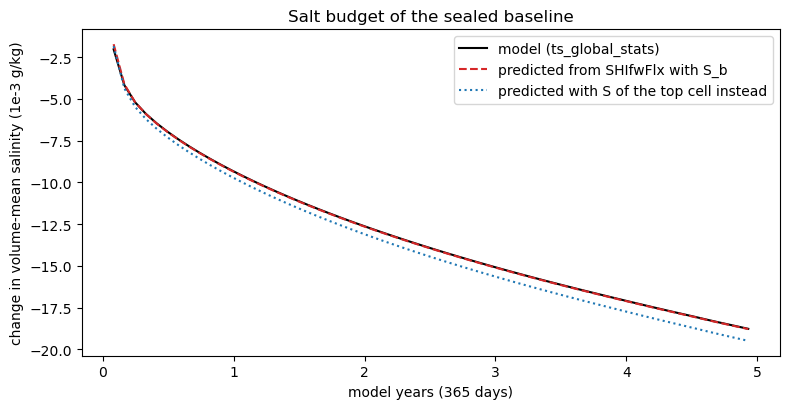

In [3]:
model_mean = []
lines = open(os.path.join(run, "ts_global_stats.0000000000.txt")).read().splitlines()
reading_salt = False
for line in lines:
    if line.startswith(" field : SALT"):
        reading_salt = True
    elif line.startswith(" field :"):
        reading_salt = False
    elif reading_salt and line.strip().startswith("0 "):
        model_mean.append(float(line.split()[1]))
model_mean = np.array(model_mean[:len(its)])
predicted_mid = 34.4 + np.cumsum(predicted_change) - predicted_change / 2
model_change = model_mean - 34.4
pred_change = predicted_mid - 34.4
print(f"after {len(its) * 30} days: model change {model_change[-1]:.4e} g/kg, predicted from the melt {pred_change[-1]:.4e} g/kg, "
      f"difference {100 * (model_change[-1] - pred_change[-1]) / pred_change[-1]:+.2f}%")
pred_change_top = np.cumsum(predicted_change_top) - predicted_change_top / 2
print(f"with S instead of S_b the prediction would be {pred_change_top[-1]:.4e} g/kg "
      f"({100 * (model_change[-1] - pred_change_top[-1]) / pred_change_top[-1]:+.2f}%)")
end_change = np.sum(s_end * cell_volume) / grid["volume"] - np.sum(s0 * cell_volume) / grid["volume"]
print(f"snapshot check, day 0 to day 1825: volume-mean salinity changed by {end_change:.4e} g/kg")
melt_volume = -np.sum([np.sum(read_field(run, "shelfice_monthly", "SHIfwFlx", it) * grid["rac"]) for it in its]) * MONTH / 1000.0
print(f"fresh water from melting over {len(its) * 30} days: {melt_volume:.4e} m^3 "
      f"({melt_volume / np.sum(grid['rac'] * grid['iced']):.3f} m spread over the ice base)")

fig, ax = plt.subplots(figsize=(8, 4.2))
months = np.arange(1, len(its) + 1) * 30 / 365
ax.plot(months, model_change * 1e3, color="k", label="model (ts_global_stats)")
ax.plot(months, pred_change * 1e3, color="tab:red", ls="--", label="predicted from SHIfwFlx with S_b")
ax.plot(months, pred_change_top * 1e3, color="tab:blue", ls=":", label="predicted with S of the top cell instead")
ax.set_xlabel("model years (365 days)")
ax.set_ylabel("change in volume-mean salinity (1e-3 g/kg)")
ax.set_title("Salt budget of the sealed baseline")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_salt_budget.png"), dpi=150)
plt.show()

## 2. Summary of all experiments

I collect the results that notebooks 02, 03, 04, 06 and 07 saved in `data/`. Every row is compared with the same steady reference, `open_p10` (far field -0.9 °C, default settings); the fine grid is compared with the coarse-grid `open_p10` over the same years.

In [4]:
def read_csv(name):
    lines = open(os.path.join(DATA_DIR, name)).read().splitlines()
    header = lines[0].split(",")
    rows = []
    for line in lines[1:]:
        rows.append(dict(zip(header, line.split(","))))
    return rows

temperature = read_csv("melt_vs_temperature.csv")
sensitivity = read_csv("melt_sensitivity.csv")
resolution = read_csv("resolution_test.csv")
isoplus = read_csv("isoplus_ocean0_results.csv")
baseline = read_csv("melt_series_baseline.csv")

reference = float(temperature[0]["steady_melt_m_per_yr"])            # open_base
reference_p10 = float(temperature[2]["steady_melt_m_per_yr"])        # step 4 reference (open_p10)
tf_p10 = float(temperature[2]["thermal_forcing_c"])
last = resolution[-1]
# each row: experiment, step, what changed, thermal forcing, melt, reference name, reference melt, note
summary = []
summary.append(("baseline (sealed)", "step 2", "no restoring (sealed box)", "-",
                np.mean([float(r["area_mean_melt_m_per_yr"]) for r in baseline[-12:]]), "-", np.nan,
                "still falling (no heat source)"))
for r in temperature:
    summary.append((r["case"], "step 3", f"far field {float(r['far_field_temperature_c']):+.1f} °C",
                    f"{float(r['thermal_forcing_c']):.2f}", float(r["steady_melt_m_per_yr"]), "open_p10", reference_p10,
                    f"change in last year {float(r['change_last_year_percent']):+.1f}%"))
for r in sensitivity:
    if r["case"] != "open_p10":
        summary.append((r["case"], "step 4", r["setting"], f"{tf_p10:.2f}", float(r["steady_melt_m_per_yr"]),
                        "open_p10", reference_p10, f"change in last year {float(r['change_last_year_percent']):+.1f}%"))
summary.append(("fine_p10", "step 6", "half the grid spacing", f"{tf_p10:.2f}", float(last["fine_melt_m_per_yr"]),
                "open_p10 (same years)", float(last["coarse_melt_m_per_yr"]), f"mean of year {last['year']}; not steady yet"))

print(f"{'experiment':18s} {'step':7s} {'what changed':38s} {'TF (°C)':>8s} {'melt (m/yr)':>12s}  {'ratio':>6s} to reference")
for name, step, change, tf, melt, ref_name, ref_melt, note in summary:
    ratio = "" if np.isnan(ref_melt) else f"{melt / ref_melt:6.2f}"
    print(f"{name:18s} {step:7s} {change:38s} {tf:>8s} {melt:12.4f}  {ratio:>6s} {ref_name} | {note}")
final = isoplus[-1]
print(f"\nISOMIP+ Ocean0 (step 7, different geometry and units): Gamma_T = {float(final['gamma_t']):.4f}, "
      f"melt where draft < -300 m {float(final['deep_melt_last6months_m_per_yr_we']):.2f} m/yr water equivalent "
      f"(target 30 +/- 2)")
with open(os.path.join(DATA_DIR, "summary_table.csv"), "w") as f:
    f.write("experiment,step,what_changed,thermal_forcing_c,melt_m_ice_per_yr,reference,ratio_to_reference,note\n")
    for name, step, change, tf, melt, ref_name, ref_melt, note in summary:
        ratio = "" if np.isnan(ref_melt) else f"{melt / ref_melt:.4f}"
        f.write(f"{name},{step},{change},{tf},{melt:.5f},{ref_name},{ratio},{note}\n")
print("saved", os.path.join(DATA_DIR, "summary_table.csv"))

experiment         step    what changed                            TF (°C)  melt (m/yr)   ratio to reference
baseline (sealed)  step 2  no restoring (sealed box)                     -       0.0386         - | still falling (no heat source)
open_base          step 3  far field -1.9 °C                          0.52       0.0252    0.12 open_p10 | change in last year -3.7%
open_p05           step 3  far field -1.4 °C                          1.02       0.1039    0.50 open_p10 | change in last year +0.2%
open_p10           step 3  far field -0.9 °C                          1.52       0.2074    1.00 open_p10 | change in last year -2.0%
open_p20           step 3  far field +0.1 °C                          2.52       0.4149    2.00 open_p10 | change in last year +0.3%
open_g05           step 4  gamma_T halved (0.5e-4 m/s)                1.52       0.1797    0.87 open_p10 | change in last year -2.0%
open_g20           step 4  gamma_T doubled (2.0e-4 m/s)               1.52       0.2336    1.13

The summary figure. Left: melt against thermal forcing on log-log axes (open circle = still falling after 20 years), with both power-law fits and the step 4 cases at their forcing (far field -0.9 °C). Right: every change compared with the same steady reference, `open_p10` (far field -0.9 °C, default settings); for the fine grid, fine / coarse over the same years.

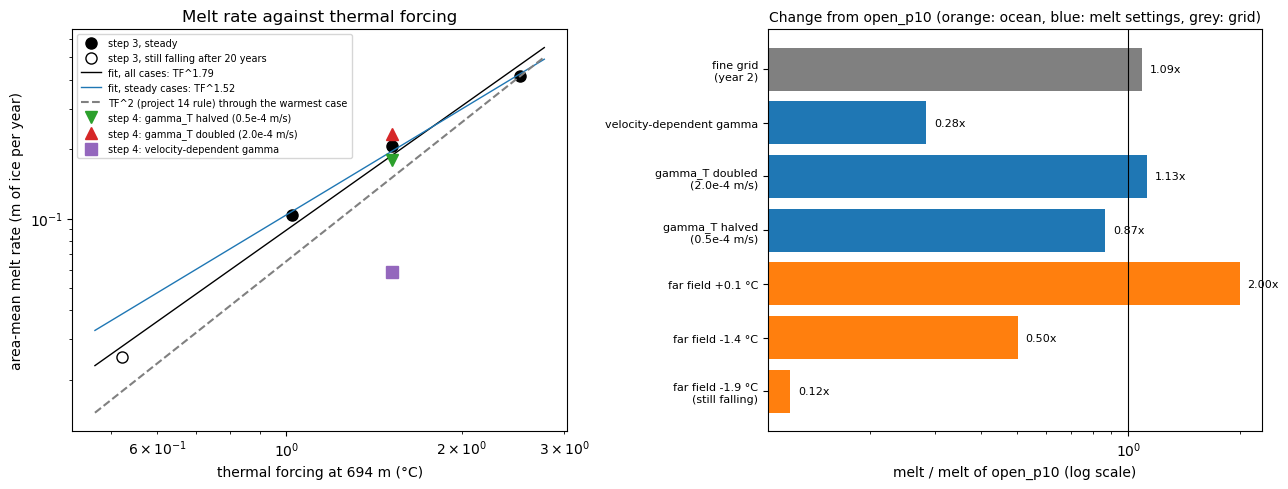

In [5]:
tf = np.array([float(r["thermal_forcing_c"]) for r in temperature])
melt = np.array([float(r["steady_melt_m_per_yr"]) for r in temperature])
steady_mask = np.array([abs(float(r["change_last_year_percent"])) < 2.0 for r in temperature])
n, log_a = np.polyfit(np.log(tf), np.log(melt), 1)
n_s, log_a_s = np.polyfit(np.log(tf[steady_mask]), np.log(melt[steady_mask]), 1)
markers = {"open_g05": ("v", "tab:green"), "open_g20": ("^", "tab:red"), "open_frict": ("s", "tab:purple")}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.loglog(tf[steady_mask], melt[steady_mask], "o", color="k", ms=8, label="step 3, steady")
ax.loglog(tf[~steady_mask], melt[~steady_mask], "o", mfc="none", color="k", ms=8, label="step 3, still falling after 20 years")
line = np.linspace(tf.min() * 0.9, tf.max() * 1.1, 50)
ax.loglog(line, np.exp(log_a) * line ** n, color="k", lw=1, label=f"fit, all cases: TF^{n:.2f}")
ax.loglog(line, np.exp(log_a_s) * line ** n_s, color="tab:blue", lw=1, label=f"fit, steady cases: TF^{n_s:.2f}")
ax.loglog(line, melt[-1] * (line / tf[-1]) ** 2, color="0.5", ls="--", label="TF^2 (project 14 rule) through the warmest case")
for r in sensitivity:
    if r["case"] in markers:
        mk, col = markers[r["case"]]
        ax.loglog([tf_p10], [float(r["steady_melt_m_per_yr"])], mk, color=col, ms=9, label=f"step 4: {r['setting']}")
ax.set_xlabel("thermal forcing at 694 m (°C)")
ax.set_ylabel("area-mean melt rate (m of ice per year)")
ax.set_title("Melt rate against thermal forcing")
ax.legend(fontsize=7)

ax = axes[1]
names = []
ratios = []
colors_bar = []
for r in temperature:
    if r["case"] != "open_p10":
        label = f"far field {float(r['far_field_temperature_c']):+.1f} °C"
        if abs(float(r["change_last_year_percent"])) >= 2.0:
            label += "\n(still falling)"
        names.append(label)
        ratios.append(float(r["steady_melt_m_per_yr"]) / reference_p10)
        colors_bar.append("tab:orange")
for r in sensitivity:
    if r["case"] != "open_p10":
        names.append(r["setting"].replace(" (", "\n("))
        ratios.append(float(r["ratio_to_reference"]))
        colors_bar.append("tab:blue")
names.append("fine grid\n(year 2)")
ratios.append(float(last["fine_over_coarse"]))
colors_bar.append("0.5")
ax.barh(range(len(names)), ratios, color=colors_bar)
ax.axvline(1, color="k", lw=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("melt / melt of open_p10 (log scale)")
ax.set_title("Change from open_p10 (orange: ocean, blue: melt settings, grey: grid)", fontsize=10)
for k, value in enumerate(ratios):
    ax.text(value * 1.05, k, f"{value:.2f}x", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_summary.png"), dpi=150)
plt.show()

## 3. What this means for the project 14 melt rule

In project 14 I assumed melt = m x T^2 with m = 10 m/yr per °C^2, where T is the temperature of the shelf water above freezing. Two questions: is the exponent 2 right, and is m = 10 a sensible size? Here T is the far-field thermal forcing, which is larger than the temperature of the water inside the cavity, so the coefficients below are lower bounds for a rule written in terms of shelf-water temperature.

In [6]:
M_P14 = 10.0     # m of ice per year per (°C)^2, from project 14 notebook 06
steady_rows = [r for r in temperature if abs(float(r["change_last_year_percent"])) < 2.0]
tf_s = np.array([float(r["thermal_forcing_c"]) for r in steady_rows])
melt_s = np.array([float(r["steady_melt_m_per_yr"]) for r in steady_rows])
n_s = np.polyfit(np.log(tf_s), np.log(melt_s), 1)[0]
print(f"exponent: {n:.2f} with all four cases, {n_s:.2f} with the steady cases only (project 14 assumed 2)")
for r in temperature:
    t = float(r["thermal_forcing_c"])
    m = float(r["steady_melt_m_per_yr"])
    print(f"{r['case']:9s}: TF {t:.2f} °C | melt {m:.4f} m/yr | melt / TF^2 = {m / t ** 2:.3f} m/yr per °C^2 | "
          f"project 14 rule would give {M_P14 * t ** 2:.2f} m/yr")
ratio_tf = tf_s[-1] / tf_s[0]
print(f"steady cases, coldest to warmest: TF grows {ratio_tf:.2f} times, melt {melt_s[-1] / melt_s[0]:.2f} times "
      f"(TF^2 would give {ratio_tf ** 2:.2f}, TF^1 {ratio_tf:.2f})")

exponent: 1.79 with all four cases, 1.52 with the steady cases only (project 14 assumed 2)
open_base: TF 0.52 °C | melt 0.0252 m/yr | melt / TF^2 = 0.093 m/yr per °C^2 | project 14 rule would give 2.72 m/yr
open_p05 : TF 1.02 °C | melt 0.1039 m/yr | melt / TF^2 = 0.100 m/yr per °C^2 | project 14 rule would give 10.43 m/yr
open_p10 : TF 1.52 °C | melt 0.2074 m/yr | melt / TF^2 = 0.090 m/yr per °C^2 | project 14 rule would give 23.15 m/yr
open_p20 : TF 2.52 °C | melt 0.4149 m/yr | melt / TF^2 = 0.065 m/yr per °C^2 | project 14 rule would give 63.57 m/yr
steady cases, coldest to warmest: TF grows 2.47 times, melt 3.99 times (TF^2 would give 6.09, TF^1 2.47)


The isomip box has a long flat ice shelf at only 200 m, where almost nothing melts, so its area-mean coefficient is small. For a second point I use ISOMIP+ Ocean0 (step 7): its far-field water at 720 m is 1.0 °C and 34.7 g/kg, and with the ISOMIP+ freezing formula (-0.0573 S + 0.0832 - 7.53e-8 p, p in Pa) that is the thermal forcing at the deepest ice. I convert its melt from water to ice (x 1000/917).

In [7]:
p_pa = 1028.0 * 9.81 * 720.0
tf_isoplus = 1.0 - (-0.0573 * 34.7 + 0.0832 - 7.53e-8 * p_pa)
deep_ice = float(final["deep_melt_last6months_m_per_yr_we"]) * 1000.0 / 917.0
whole_ice = float(final["whole_shelf_melt_last6months_m_per_yr_we"]) * 1000.0 / 917.0
print(f"ISOMIP+ thermal forcing at 720 m: {tf_isoplus:.2f} °C")
print(f"ISOMIP+ deep melt {deep_ice:.1f} m of ice/yr -> melt / TF^2 = {deep_ice / tf_isoplus ** 2:.2f} m/yr per °C^2")
print(f"ISOMIP+ whole-shelf melt {whole_ice:.1f} m of ice/yr -> melt / TF^2 = {whole_ice / tf_isoplus ** 2:.2f} m/yr per °C^2")

ISOMIP+ thermal forcing at 720 m: 3.45 °C
ISOMIP+ deep melt 32.2 m of ice/yr -> melt / TF^2 = 2.70 m/yr per °C^2
ISOMIP+ whole-shelf melt 11.8 m of ice/yr -> melt / TF^2 = 0.99 m/yr per °C^2
